# Importing Library

In [1]:
import os, random, warnings
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, applications, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import kagglehub
import shutil

In [2]:
# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")
print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:05<00:00, 22.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1


In [3]:
# Original path from KaggleHub
src_path =r"/root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1"

# Destination path in /content
dst_path = "/content/brian-tumor-dataset"

# Copy the dataset
shutil.copytree(src_path, dst_path)

print("Dataset copied to:", dst_path)


Dataset copied to: /content/brian-tumor-dataset


In [4]:
def rename_files_and_folders(root_dir):
    for dirpath, dirnames, filenames in os.walk(root_dir, topdown=False):
        # Rename files
        for filename in filenames:
            new_name = filename.replace(' ', '_').lower()
            if new_name != filename:
                os.rename(os.path.join(dirpath, filename), os.path.join(dirpath, new_name))

        # Rename directories
        for dirname in dirnames:
            new_dirname = dirname.replace(' ', '_').lower()
            if new_dirname != dirname:
                os.rename(os.path.join(dirpath, dirname), os.path.join(dirpath, new_dirname))

# Usage
root_directory = '/content/brian-tumor-dataset/Brain Tumor Data Set'
rename_files_and_folders(root_directory)


In [5]:
# Corrected path for the main dataset directory after renaming
main_dir = "/content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set"

print(f"Contents of {main_dir}:")
if os.path.exists(main_dir):
    print(os.listdir(main_dir))

    # Explore the 'brain_tumor' and 'healthy' directories to confirm image presence
    brain_tumor_images_dir = os.path.join(main_dir, "brain_tumor")
    if os.path.exists(brain_tumor_images_dir):
        print(f"\nContents of {brain_tumor_images_dir} (first 5):")
        print(os.listdir(brain_tumor_images_dir)[:5])
    else:
        print(f"\nError: Directory not found: {brain_tumor_images_dir}")

    healthy_images_dir = os.path.join(main_dir, "healthy")
    if os.path.exists(healthy_images_dir):
        print(f"\nContents of {healthy_images_dir} (first 5):")
        print(os.listdir(healthy_images_dir)[:5])
    else:
        print(f"\nError: Directory not found: {healthy_images_dir}")
else:
    print(f"Error: Main directory not found: {main_dir}")

Contents of /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set:
['healthy', 'brain_tumor']

Contents of /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor (first 5):
['cancer_(1142).jpg', 'cancer_(1532).jpg', 'cancer_(2312).jpg', 'cancer_(16).jpg', 'cancer_(1565).jpg']

Contents of /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/healthy (first 5):
['not_cancer__(1911).jpg', 'not_cancer__(1221).jpg', 'not_cancer__(1153).jpg', 'not_cancer__(1135).jpg', 'not_cancer__(1402).jpg']


In [6]:
# Define the paths to the image directories
brain_tumor_dir = "/content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor"
healthy_dir = "/content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/healthy"

# Get list of filenames in each directory
brain_tumor_filenames = os.listdir(brain_tumor_dir)
healthy_filenames = os.listdir(healthy_dir)

# Construct full paths for each image
brain_tumor_paths = [os.path.join(brain_tumor_dir, f) for f in brain_tumor_filenames]
healthy_paths = [os.path.join(healthy_dir, f) for f in healthy_filenames]

# Print the number of images found in each category
print(f"Found {len(brain_tumor_paths)} brain tumor images.")
print(f"Found {len(healthy_paths)} healthy images.")

Found 2513 brain tumor images.
Found 2087 healthy images.


# loading dataset to brain_tumor_directory

In [7]:
warnings.filterwarnings("ignore")
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ==========================================================
# CONFIG
# ==========================================================
BRAIN_TUMOR_DIR = Path("/content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor")
HEALTHY_DIR = Path("/content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/healthy")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


```
#  ENHANCED CLEANING WITH TENSORFLOW VALIDATION
```


In [8]:
# ==========================================================
#  ENHANCED CLEANING WITH TENSORFLOW VALIDATION
# ==========================================================
def clean_directory_with_tf(directory):
    """
    Clean dataset using both PIL and TensorFlow validation.
    """
    removed = 0
    for root, _, files in os.walk(directory):
        for f in files:
            ext = os.path.splitext(f)[-1].lower()
            path = os.path.join(root, f)

            # Remove non-image extensions
            if ext not in [".jpg", ".jpeg", ".png", ".bmp", ".gif"]:
                try:
                    os.remove(path)
                    removed += 1
                except:
                    pass
                continue

            # Validate with PIL
            try:
                with Image.open(path) as im:
                    im.verify()
                with Image.open(path) as im:
                    im.load()
            except Exception:
                try:
                    os.remove(path)
                    removed += 1
                except:
                    pass
                continue

            # Validate with TensorFlow
            try:
                img_bytes = tf.io.read_file(path)
                img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
                _ = img.shape
            except Exception:
                try:
                    os.remove(path)
                    removed += 1
                    print(f"⚠️ Removed TF-incompatible: {path}")
                except:
                    pass
                continue

    print(f"⛹️ Cleaned dataset. Removed {removed} invalid/corrupt files.")

print("⛹️ Cleaning brain tumor images...")
clean_directory_with_tf(BRAIN_TUMOR_DIR)
print("⛹️ Cleaning healthy images...")
clean_directory_with_tf(HEALTHY_DIR)

⛹️ Cleaning brain tumor images...
⛹️ Cleaned dataset. Removed 86 invalid/corrupt files.
⛹️ Cleaning healthy images...
⛹️ Cleaned dataset. Removed 0 invalid/corrupt files.




```
# BUILD DATAFRAME (Binary Classification)
```



In [9]:
# ==========================================================
#  BUILD DATAFRAME (Binary Classification)
# ==========================================================
def build_dataframe(tumor_dir: Path, healthy_dir: Path):
    rows = []

    # Add brain tumor images (label = 1)
    for img in tumor_dir.glob("*.*"):
        if img.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".gif"]:
            rows.append({
                "filepath": str(img),
                "label": "tumor",
                "class_id": 1
            })

    # Add healthy images (label = 0)
    for img in healthy_dir.glob("*.*"):
        if img.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".gif"]:
            rows.append({
                "filepath": str(img),
                "label": "healthy",
                "class_id": 0
            })

    df = pd.DataFrame(rows)
    print(f"✅ Total images: {len(df)}")
    print(f"   - Brain tumor: {len(df[df['label']=='tumor'])}")
    print(f"   - Healthy: {len(df[df['label']=='healthy'])}")
    return df

df = build_dataframe(BRAIN_TUMOR_DIR, HEALTHY_DIR)

✅ Total images: 4514
   - Brain tumor: 2427
   - Healthy: 2087




```
# TRAIN / VAL / TEST SPLIT
```



In [10]:
# ==========================================================
#  TRAIN / VAL / TEST SPLIT
# ==========================================================
trainval_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df["class_id"], random_state=SEED
)
train_df, val_df = train_test_split(
    trainval_df, test_size=0.15, stratify=trainval_df["class_id"], random_state=SEED
)

print(f"\n📊 Dataset Split:")
print(f"   Train: {len(train_df)} ({len(train_df[train_df['label']=='tumor'])} tumor, {len(train_df[train_df['label']=='healthy'])} healthy)")
print(f"   Val:   {len(val_df)} ({len(val_df[val_df['label']=='tumor'])} tumor, {len(val_df[val_df['label']=='healthy'])} healthy)")
print(f"   Test:  {len(test_df)} ({len(test_df[test_df['label']=='tumor'])} tumor, {len(test_df[test_df['label']=='healthy'])} healthy)")


📊 Dataset Split:
   Train: 3260 (1752 tumor, 1508 healthy)
   Val:   576 (310 tumor, 266 healthy)
   Test:  678 (365 tumor, 313 healthy)


In [11]:
test_df

,filepath,label,class_id
1276,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1
1851,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1
1347,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1
983,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1
813,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1
...,...,...,...
4186,/content/brian-tumor-dataset/Brain Tumor Data ...,healthy,0
3152,/content/brian-tumor-dataset/Brain Tumor Data ...,healthy,0
129,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1
4016,/content/brian-tumor-dataset/Brain Tumor Data ...,healthy,0


In [12]:
import os
import shutil

# Create destination folder
dst_folder = "/content/test_image"
os.makedirs(dst_folder, exist_ok=True)

# Copy images from test_df to dst_folder
for src_path in test_df["filepath"]:
    # Only copy files if they exist
    if os.path.isfile(src_path):
        shutil.copy(src_path, dst_folder)

# Zip the folder for download
shutil.make_archive("test_image", 'zip', dst_folder)

# Provide download link in Colab
from google.colab import files
files.download("test_image.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



```
# Class Weights Calculation
```



In [8]:
class_weights = compute_class_weight('balanced', classes=np.unique(train_df["class_id"]), y=train_df["class_id"])
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0809018567639257), 1: np.float64(0.930365296803653)}




```
# ENHANCED AUGMENTATION FOR MEDICAL IMAGES
```



In [7]:
# ==========================================================
#  ENHANCED AUGMENTATION FOR MEDICAL IMAGES
# ==========================================================

# Instantiate rotation layer once globally
# The factor for RandomRotation represents a fraction of 2*pi radians.
# 15 degrees = 15 * (pi/180) radians = pi/12 radians.
# To get a range of [-pi/12, pi/12], the factor range should be
# [-(pi/12)/(2*pi), (pi/12)/(2*pi)] = [-1/24, 1/24]
rotation_factor = 15.0 / 360.0 # equivalent to 15 degrees / 360 degrees, as a fraction of full circle
global_rotation_layer = layers.RandomRotation(
    factor=(-rotation_factor, rotation_factor),
    fill_mode='nearest',
    interpolation='bilinear',
    seed=SEED # ensure reproducibility
)

def augment_image(img):
    """
    Medical image-specific augmentation.
    Avoid aggressive color changes for MRI/CT scans.
    """
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    # Slight rotation using the pre-instantiated Keras layer
    img = global_rotation_layer(img)

    # Brightness and contrast (subtle for medical images)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)

    # Zoom augmentation
    if tf.random.uniform([]) > 0.5:
        # Corrected zoom_factor for central_crop: should be between 0 and 1
        # A smaller fraction means zooming in more.
        zoom_factor_fraction = tf.random.uniform([], 0.7, 1.0) # Adjusted range
        img = tf.image.central_crop(img, zoom_factor_fraction)
        img = tf.image.resize(img, IMG_SIZE)

    return img

def load_and_preprocess(path, label):
    """
    Robust image loader with error handling.
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, augment=False, shuffle=False):
    files = df["filepath"].values
    labels = df["class_id"].values

    ds = tf.data.Dataset.from_tensor_slices((files, labels))

    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )

    if augment:
        ds = ds.map(
            lambda x, y: (augment_image(x), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

# Create datasets
train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds = make_dataset(val_df, augment=False, shuffle=False)
test_ds = make_dataset(test_df, augment=False, shuffle=False)

print("\n✅ Datasets created successfully!")


✅ Datasets created successfully!




---


```
#  TRANSFER LEARNING MODEL (Binary Classification)
```




In [8]:
# ==========================================================
#  TRANSFER LEARNING MODEL (Binary Classification)
# ==========================================================
def build_transfer_model():
    """
    EfficientNetB3 for binary brain tumor classification.
    """
    base = applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
        pooling="avg"
    )
    base.trainable = False

    inputs = layers.Input(shape=(*IMG_SIZE, 3))

    # EfficientNet preprocessing
    x = applications.efficientnet.preprocess_input(inputs * 255.0)
    x = base(x, training=False)

    # Enhanced classification head
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)

    # Binary classification output
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )

    return model, base

model, base_model = build_transfer_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,217,200 (42.79 MB)

 Trainable params: 430,081 (1.64 MB)

 Non-trainable params: 10,787,119 (41.15 MB)



```
# TRAINING PHASE 1: HEAD ONLY
```



In [9]:
# ==========================================================
#  TRAINING PHASE 1: HEAD ONLY
# ==========================================================
ckpt = callbacks.ModelCheckpoint(
    "brain_tumor_stage1.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

es = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("\n🚀 Training Phase 1: Head Only (15 epochs)")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[ckpt, es, reduce_lr],
    verbose=1
)



🚀 Training Phase 1: Head Only (15 epochs)
Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.7437 - auc: 0.8160 - loss: 5.9151 - precision: 0.7517 - recall: 0.7747
Epoch 1: val_accuracy improved from -inf to 0.90625, saving model to brain_tumor_stage1.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 136s 835ms/step - accuracy: 0.7443 - auc: 0.8167 - loss: 5.9071 - precision: 0.7524 - recall: 0.7750 - val_accuracy: 0.9062 - val_auc: 0.9658 - val_loss: 3.6256 - val_precision: 0.9156 - val_recall: 0.9097 - learning_rate: 0.0010
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.8565 - auc: 0.9331 - loss: 3.2182 - precision: 0.8722 - recall: 0.8574
Epoch 2: val_accuracy improved from 0.90625 to 0.91319, saving model to brain_tumor_stage1.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 38s 371ms/step - accuracy: 0.8566 - auc: 0.9332 - loss: 3.2143 - precision: 0.8723 - recall: 0.8575 - val_accuracy: 0.9132 - val_auc: 0.9796 - val_loss: 2.0542 - val_precision: 0.8892 - val_recall: 0.



```
#  FINE-TUNING PHASE
```



In [10]:
# ==========================================================
#  FINE-TUNING PHASE
# ==========================================================
print("\n🔥 Training Phase 2: Fine-tuning Top Layers")

# Unfreeze last 40 layers for medical imaging
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-6),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

ckpt2 = callbacks.ModelCheckpoint(
    "brain_tumor_finetuned.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

es2 = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[ckpt2, es2, reduce_lr],
    verbose=1
)


🔥 Training Phase 2: Fine-tuning Top Layers
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8347 - auc: 0.9086 - loss: 0.7758 - precision: 0.8471 - recall: 0.8514
Epoch 1: val_accuracy improved from -inf to 0.92014, saving model to brain_tumor_finetuned.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 117s 650ms/step - accuracy: 0.8348 - auc: 0.9086 - loss: 0.7757 - precision: 0.8471 - recall: 0.8515 - val_accuracy: 0.9201 - val_auc: 0.9788 - val_loss: 0.5620 - val_precision: 0.9151 - val_recall: 0.9387 - learning_rate: 5.0000e-06
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8498 - auc: 0.9235 - loss: 0.7318 - precision: 0.8565 - recall: 0.8681
Epoch 2: val_accuracy did not improve from 0.92014
102/102 ━━━━━━━━━━━━━━━━━━━━ 26s 250ms/step - accuracy: 0.8499 - auc: 0.9235 - loss: 0.7317 - precision: 0.8565 - recall: 0.8682 - val_accuracy: 0.9062 - val_auc: 0.9759 - val_loss: 0.5716 - val_precision: 0.9103 - val_recall: 0.9161 - learning_rate: 5.0000e-06
Epoch



```
# EVALUATION
```



In [11]:
# ==========================================================
#  EVALUATION
# ==========================================================
print("\n" + "="*60)
print("📊 FINAL EVALUATION ON TEST SET")
print("="*60)

test_results = model.evaluate(test_ds, verbose=1)
print(f"\n✅ Test Loss:      {test_results[0]:.4f}")
print(f"✅ Test Accuracy:  {test_results[1]:.4f}")
print(f"✅ Test AUC:       {test_results[2]:.4f}")
print(f"✅ Test Precision: {test_results[3]:.4f}")
print(f"✅ Test Recall:    {test_results[4]:.4f}")

# Calculate F1-Score
f1_score = 2 * (test_results[3] * test_results[4]) / (test_results[3] + test_results[4])
print(f"✅ Test F1-Score:  {f1_score:.4f}")


📊 FINAL EVALUATION ON TEST SET
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 790ms/step - accuracy: 0.9519 - auc: 0.9928 - loss: 0.4858 - precision: 0.9480 - recall: 0.9688

✅ Test Loss:      0.4908
✅ Test Accuracy:  0.9528
✅ Test AUC:       0.9912
✅ Test Precision: 0.9488
✅ Test Recall:    0.9644
✅ Test F1-Score:  0.9565




```
#  SAVE FINAL MODEL
```



In [12]:
# ==========================================================
#  SAVE FINAL MODEL
# ==========================================================
model.save("final_brain_tumor_model_95.keras")
print("\n💾 Model saved as 'final_brain_tumor_model.keras'")



💾 Model saved as 'final_brain_tumor_model.keras'




```
# DETAILED PREDICTIONS ON TEST SET
```




🔍 GENERATING DETAILED PREDICTIONS
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 550ms/step

📋 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.94      0.95       313
       Tumor       0.95      0.96      0.96       365

    accuracy                           0.95       678
   macro avg       0.95      0.95      0.95       678
weighted avg       0.95      0.95      0.95       678



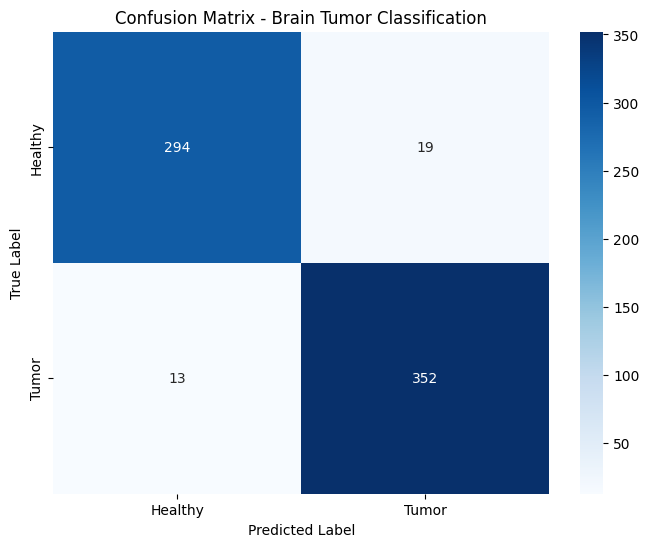


✅ Confusion matrix saved as 'confusion_matrix.png'


In [13]:
# ==========================================================
#  DETAILED PREDICTIONS ON TEST SET
# ==========================================================
print("\n" + "="*60)
print("🔍 GENERATING DETAILED PREDICTIONS")
print("="*60)

predictions = model.predict(test_ds)
pred_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_df["class_id"].values

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=["Healthy", "Tumor"]))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Tumor"],
            yticklabels=["Healthy", "Tumor"])
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Confusion matrix saved as 'confusion_matrix.png'")

loading model for testing

In [15]:
import tensorflow as tf
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Reload test DataFrame
# test_df = pd.read_csv("test_df.csv") # Use this if you saved test_df; else skip

# Load model
model = tf.keras.models.load_model("final_brain_tumor_model_95.keras")


In [16]:
IMG_SIZE = (224, 224)

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    return img

# Predict all at once
imgs = np.stack([load_image(f).numpy() for f in test_df["filepath"]])
preds = model.predict(imgs, batch_size=32, verbose=1)
pred_classes = (preds > 0.5).astype(int).flatten()
true_classes = test_df["class_id"].values
filepaths = test_df["filepath"].values


22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 580ms/step


# Show first 25 images and their prediction/actual


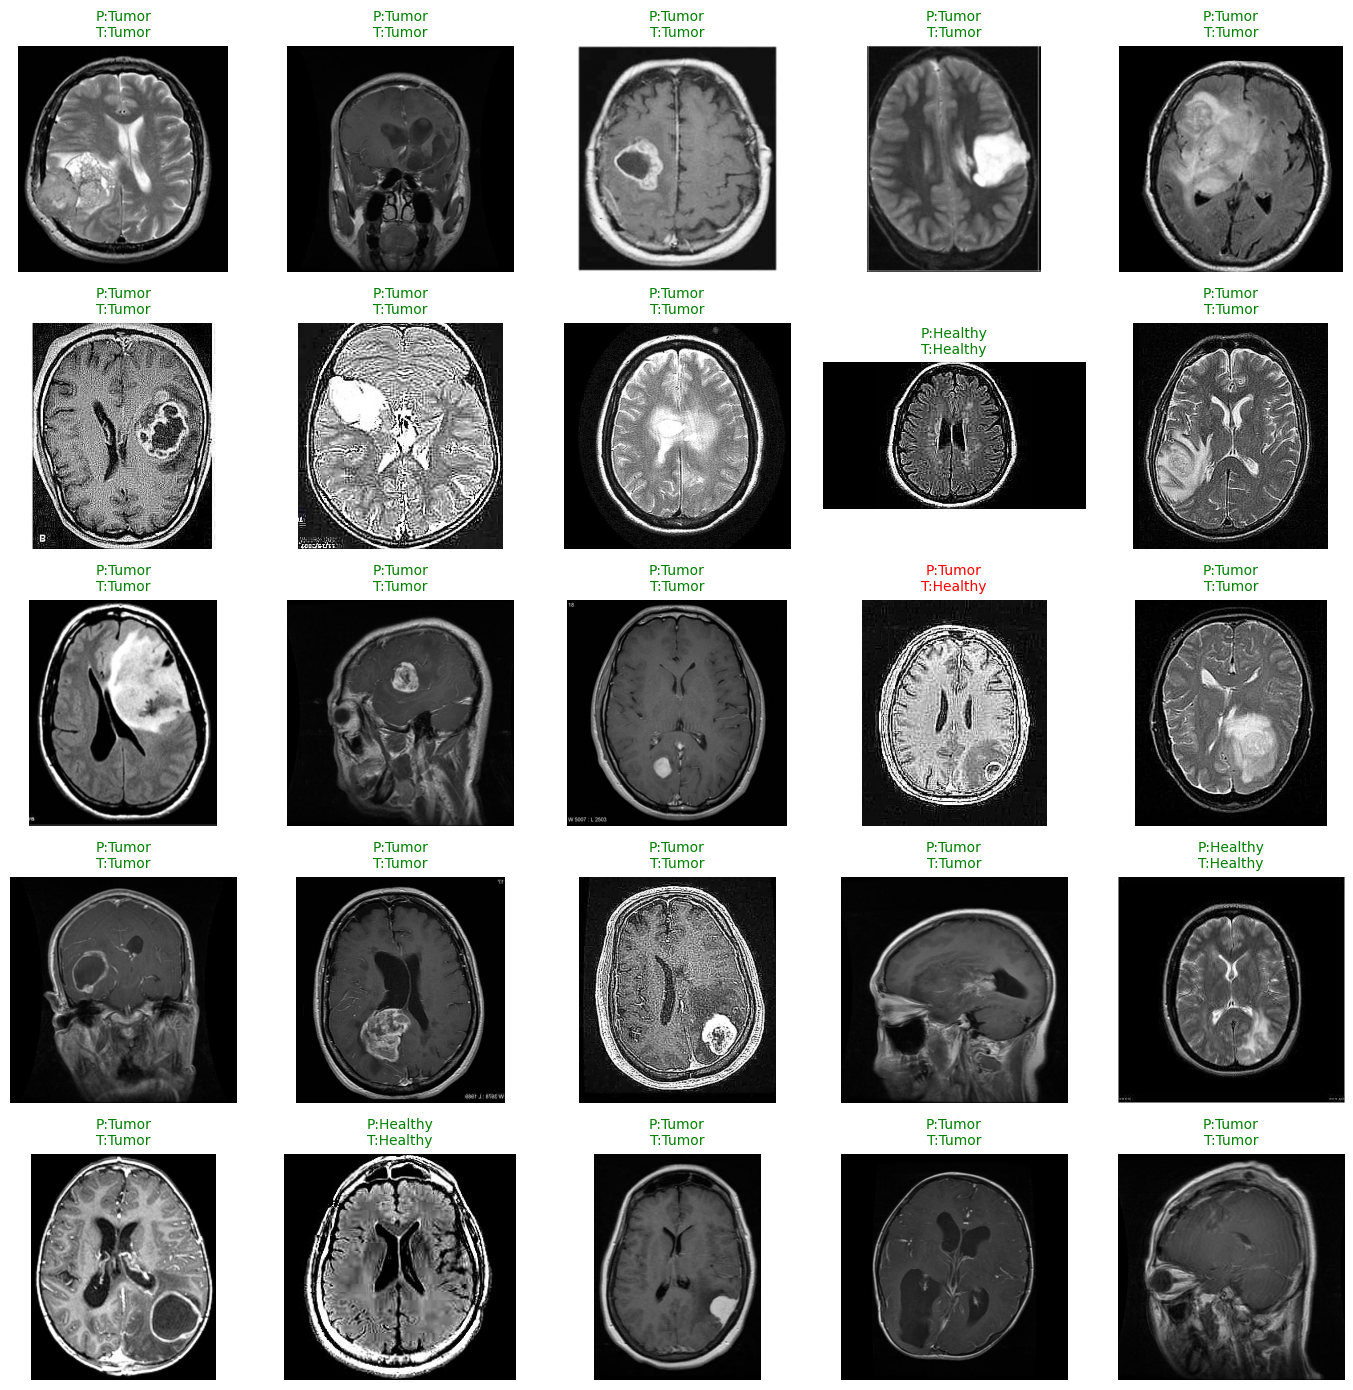

In [17]:
class_names = ["Healthy", "Tumor"]

def show_images_with_preds(filepaths, pred_classes, true_classes, n=25):
    plt.figure(figsize=(14, 14))
    for i in range(n):
        ax = plt.subplot(5, 5, i+1)
        img = Image.open(filepaths[i])
        plt.imshow(img, cmap="gray")
        pred = class_names[pred_classes[i]]
        actual = class_names[true_classes[i]]
        color = "green" if pred == actual else "red"
        plt.title(f"P:{pred}\nT:{actual}", color=color, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Show first 25 images and their prediction/actual
show_images_with_preds(filepaths, pred_classes, true_classes, n=25)


# Show first 25 wrong


Number of misclassified: 32


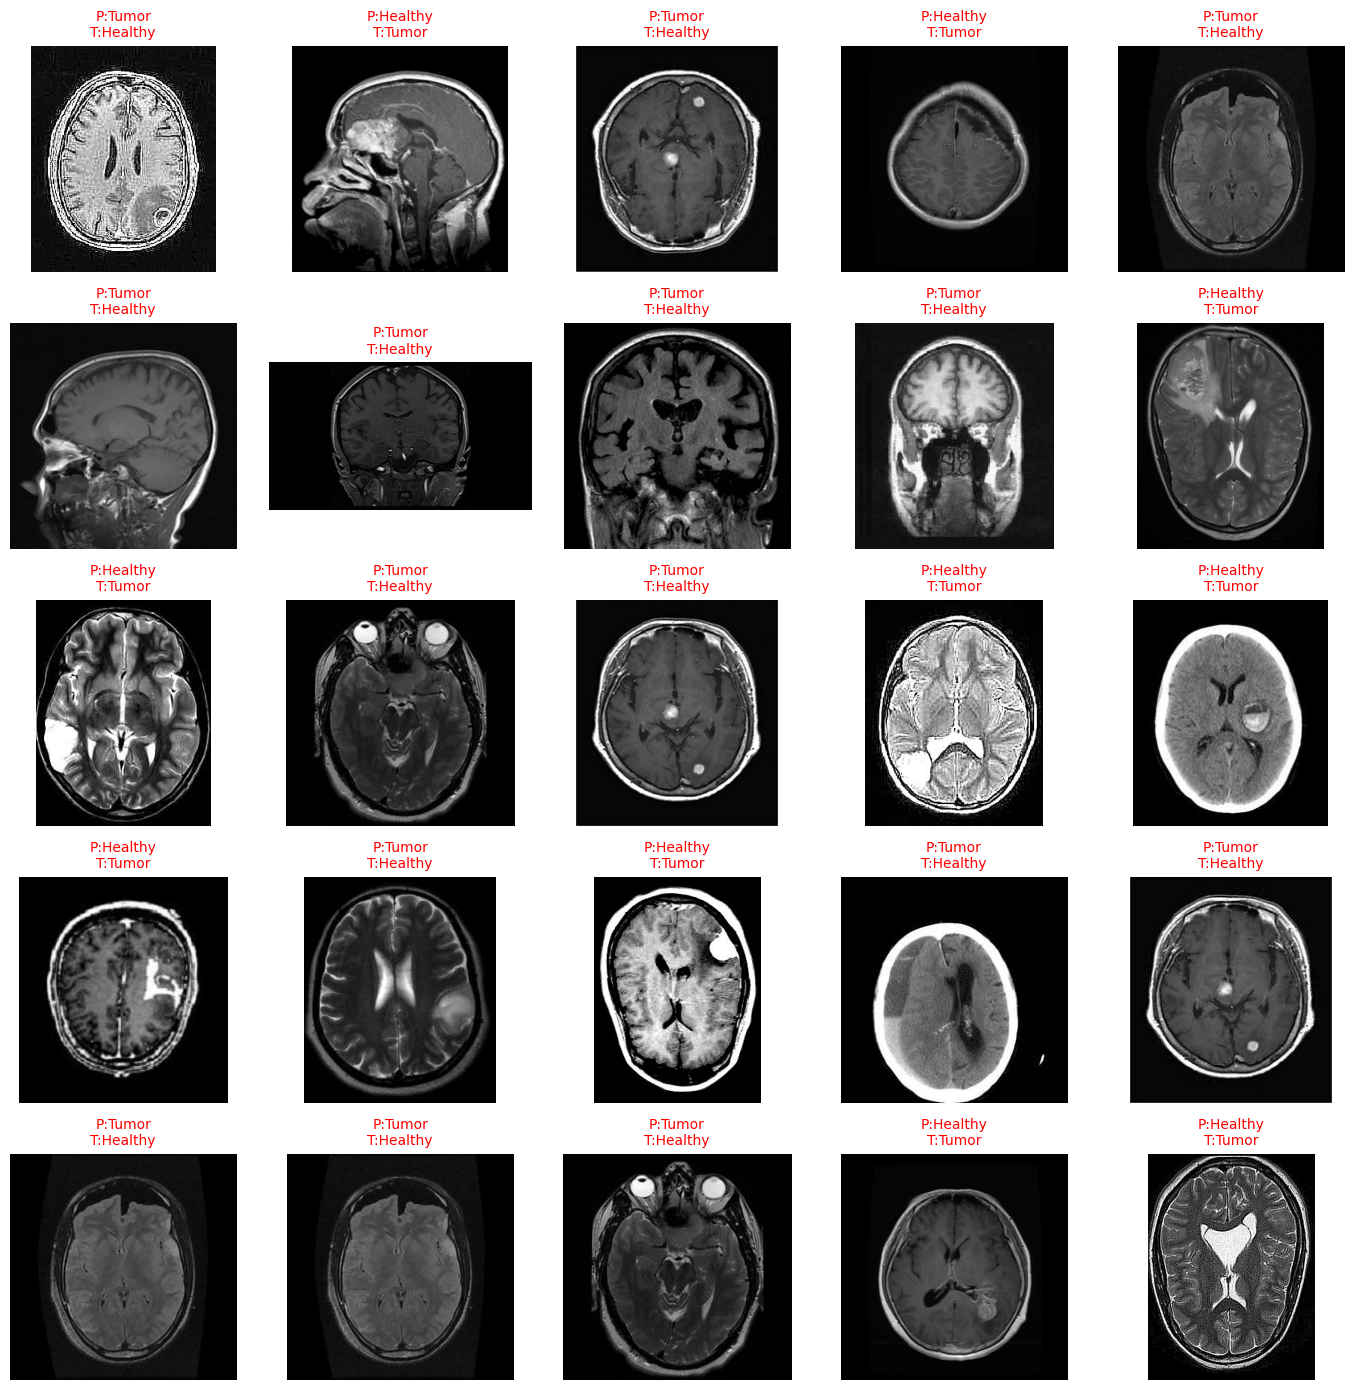

In [18]:
wrong_idx = np.where(pred_classes != true_classes)[0]
print(f"Number of misclassified: {len(wrong_idx)}")
# Show first 25 wrong
show_images_with_preds(filepaths[wrong_idx], pred_classes[wrong_idx], true_classes[wrong_idx], n=min(25, len(wrong_idx)))


In [19]:
# After getting pred_classes and true_classes
total_images = len(true_classes)
total_correct = (pred_classes == true_classes).sum()
total_wrong = (pred_classes != true_classes).sum()

print(f"Total images: {total_images}")
print(f"✔️ Correct predictions: {total_correct}")
print(f"❌ Wrong predictions:   {total_wrong}")
print(f"Accuracy: {total_correct/total_images:.4f}")


Total images: 678
✔️ Correct predictions: 646
❌ Wrong predictions:   32
Accuracy: 0.9528


#improving the 95 to something

> Data Augmentation (Albumentations via TF wrapper)




In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

AUG = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.5, alpha=1, sigma=20, alpha_affine=10),
    A.GaussNoise(p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.CLAHE(p=0.2, clip_limit=2),
    A.Resize(*IMG_SIZE),
])

def albumentations_aug(img):
    img = img.numpy()
    if img.max() <= 1: img = (img * 255).astype(np.uint8)
    if img.shape[-1] == 1: img = np.repeat(img, 3, axis=-1)
    return AUG(image=img)['image']

def tf_albumentations(img, label):
    aug_img = tf.numpy_function(albumentations_aug, [img], tf.uint8)
    aug_img = tf.image.convert_image_dtype(aug_img, tf.float32)
    return aug_img, label


Dataset Function

In [10]:
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df["filepath"].values, df["class_id"].values))
    if shuffle: ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.map(tf_albumentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds = make_dataset(val_df, augment=False)
test_ds = make_dataset(test_df, augment=False)


Model Build & Training: EfficientNetB3 + Fine-tuning


In [11]:
def build_transfer_model():
    base = applications.EfficientNetB3(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3), pooling="avg")
    base.trainable = False
    x = inputs = layers.Input(shape=(*IMG_SIZE, 3))
    y = applications.efficientnet.preprocess_input(x * 255.0)
    y = base(y, training=False)
    y = layers.BatchNormalization()(y)
    y = layers.Dropout(0.5)(y)
    y = layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.05))(y)
    y = layers.BatchNormalization()(y)
    y = layers.Dropout(0.4)(y)
    y = layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.05))(y)
    y = layers.Dropout(0.3)(y)
    outputs = layers.Dense(1, activation="sigmoid")(y)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall")])
    return model, base

model, base_model = build_transfer_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,217,200 (42.79 MB)

 Trainable params: 430,081 (1.64 MB)

 Non-trainable params: 10,787,119 (41.15 MB)

In [12]:
ckpt = callbacks.ModelCheckpoint("improvement_head.keras", save_best_only=True, monitor="val_accuracy", mode="max", verbose=1)
es = callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, min_lr=1e-7, factor=0.5, verbose=1)

Train Head
with 15 epochs

In [13]:
# Load all train images and labels into numpy arrays
def dataset_to_numpy(df):
    images = []
    labels = []
    for img_path, label in zip(df["filepath"], df["class_id"]):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, IMG_SIZE)
        images.append(img.numpy())
        labels.append(label)
    return np.array(images), np.array(labels)

x_train, y_train = dataset_to_numpy(train_df)
x_val, y_val = dataset_to_numpy(val_df)

# Now fit with class_weight!
history1 = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=15,
    callbacks=[ckpt, es, reduce_lr],
    verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.7895 - auc: 0.8675 - loss: 19.4043 - precision: 0.8129 - recall: 0.8021
Epoch 1: val_accuracy improved from -inf to 0.91493, saving model to improvement_head.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 105s 512ms/step - accuracy: 0.7900 - auc: 0.8680 - loss: 19.3308 - precision: 0.8135 - recall: 0.8024 - val_accuracy: 0.9149 - val_auc: 0.9744 - val_loss: 2.9982 - val_precision: 0.9015 - val_recall: 0.9452 - learning_rate: 0.0010
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9015 - auc: 0.9663 - loss: 1.9750 - precision: 0.9216 - recall: 0.8939
Epoch 2: val_accuracy did not improve from 0.91493
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9015 - auc: 0.9663 - loss: 1.9701 - precision: 0.9216 - recall: 0.8939 - val_accuracy: 0.9149 - val_auc: 0.9768 - val_loss: 0.9450 - val_precision: 0.8896 - val_recall: 0.9613 - learning_rate: 0.0010
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy

In [16]:
# UNFREEZE layers AFTER head training, before fine-tuning! (do NOT run .fit before this step)
for layer in base_model.layers[-30:]:
    layer.trainable = True

# RE-COMPILE the model after unfreezing, using the same optimizer/loss/metrics
model.compile(
    optimizer=optimizers.Adam(learning_rate=7e-6),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

# THEN run fit for fine-tuning (with class weights or without)
history2 = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=10,
    callbacks=[ckpt2, es2, reduce_lr],
    verbose=1,
    class_weight=class_weight_dict
)


Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.8567 - auc: 0.9334 - loss: 0.7204 - precision: 0.8674 - recall: 0.8678
Epoch 1: val_accuracy improved from -inf to 0.94792, saving model to best_finetuned.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 99s 477ms/step - accuracy: 0.8568 - auc: 0.9335 - loss: 0.7201 - precision: 0.8675 - recall: 0.8680 - val_accuracy: 0.9479 - val_auc: 0.9932 - val_loss: 0.4916 - val_precision: 0.9762 - val_recall: 0.9258 - learning_rate: 7.0000e-06
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9080 - auc: 0.9607 - loss: 0.6237 - precision: 0.9157 - recall: 0.9141
Epoch 2: val_accuracy improved from 0.94792 to 0.95486, saving model to best_finetuned.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.9081 - auc: 0.9607 - loss: 0.6235 - precision: 0.9157 - recall: 0.9141 - val_accuracy: 0.9549 - val_auc: 0.9930 - val_loss: 0.4823 - val_precision: 0.9733 - val_recall: 0.9419 - learning_rate: 7.0000e-06
Epoch 3/10
102/1

In [17]:
val_pred = model.predict(val_ds)
val_true = val_df["class_id"].values
from sklearn.metrics import f1_score
best_f1 = 0; best_thresh = 0.5
for thresh in np.arange(0.3, 0.7, 0.01):
    f1 = f1_score(val_true, (val_pred > thresh).astype(int))
    if f1 > best_f1: best_f1, best_thresh = f1, thresh
print(f"Best threshold: {best_thresh:.2f} | Val F1: {best_f1:.4f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step
Best threshold: 0.40 | Val F1: 0.9806


22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 938ms/step
              precision    recall  f1-score   support

     Healthy       0.97      0.99      0.98       313
       Tumor       0.99      0.97      0.98       365

    accuracy                           0.98       678
   macro avg       0.98      0.98      0.98       678
weighted avg       0.98      0.98      0.98       678



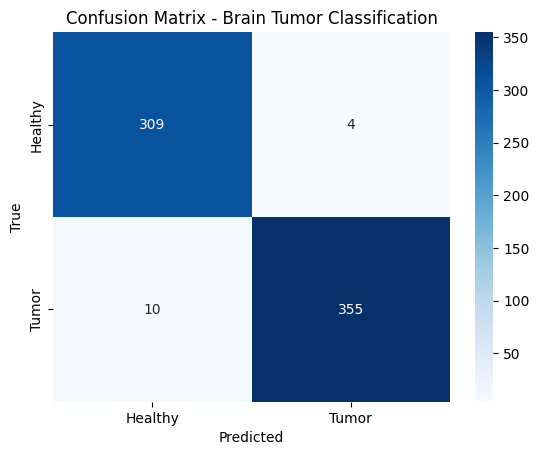

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_pred = model.predict(test_ds)
test_classes = (test_pred > best_thresh).astype(int).flatten()
test_true = test_df["class_id"].values

print(classification_report(test_true, test_classes, target_names=["Healthy", "Tumor"]))
cm = confusion_matrix(test_true, test_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Tumor"], yticklabels=["Healthy", "Tumor"])
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()


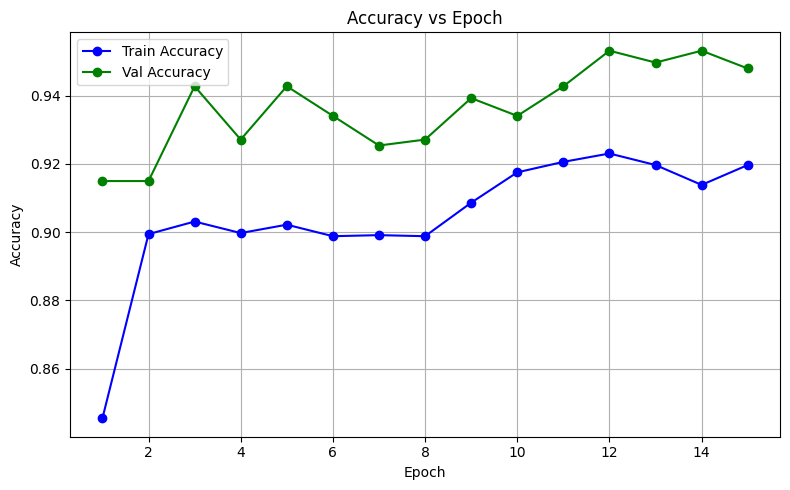

In [30]:
import matplotlib.pyplot as plt

# Use your history object from training (e.g., history1, history2)
history = history1  # Or history2 if you want fine-tuning phase

epochs = range(1, len(history.history["accuracy"]) + 1)
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
plt.plot(epochs, val_acc, 'g-o', label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


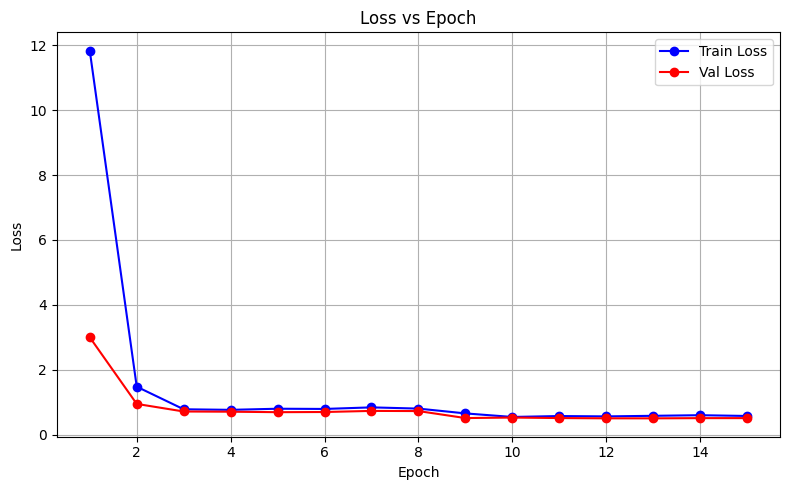

In [31]:
plt.figure(figsize=(8,5))
plt.plot(epochs, history.history["loss"], 'b-o', label='Train Loss')
plt.plot(epochs, history.history["val_loss"], 'r-o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


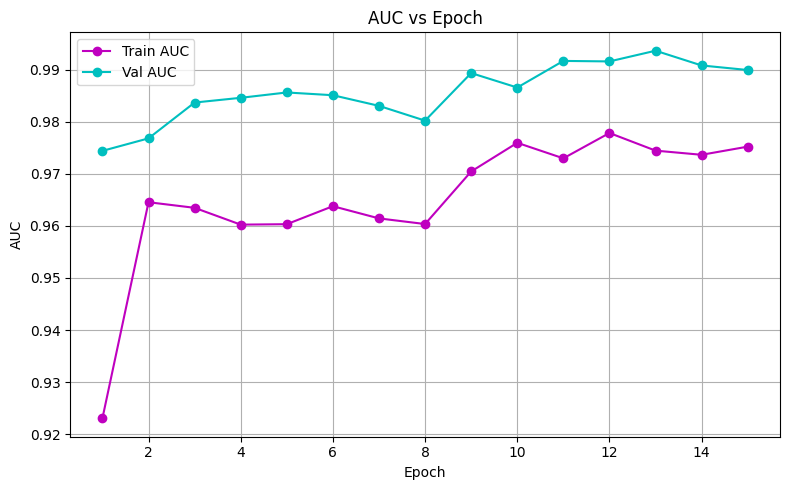

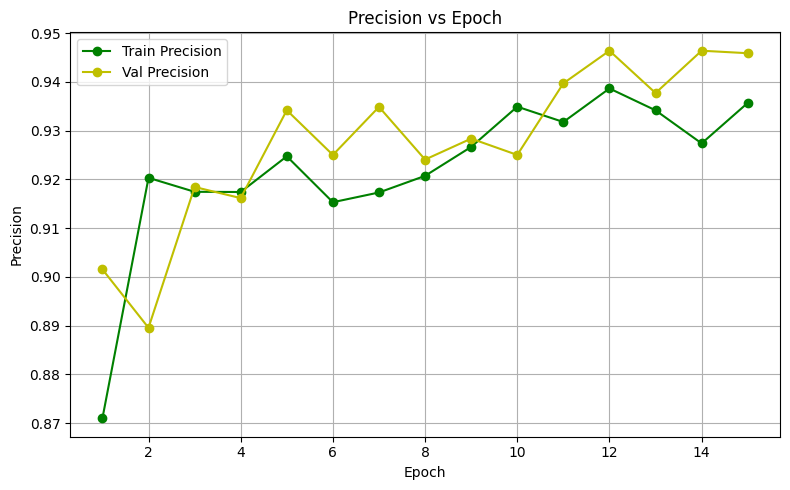

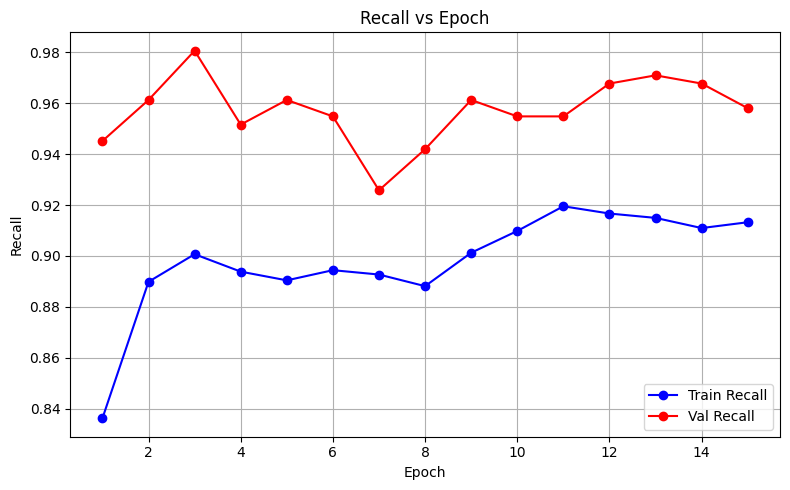

In [32]:
plt.figure(figsize=(8,5))
plt.plot(epochs, history.history["auc"], 'm-o', label='Train AUC')
plt.plot(epochs, history.history["val_auc"], 'c-o', label='Val AUC')
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("AUC vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, history.history["precision"], 'g-o', label='Train Precision')
plt.plot(epochs, history.history["val_precision"], 'y-o', label='Val Precision')
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Precision vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, history.history["recall"], 'b-o', label='Train Recall')
plt.plot(epochs, history.history["val_recall"], 'r-o', label='Val Recall')
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Recall vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


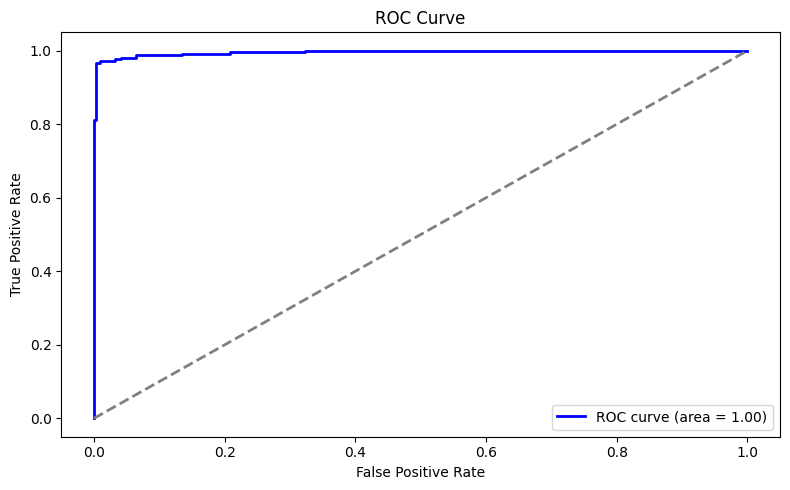

In [33]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(test_true, test_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


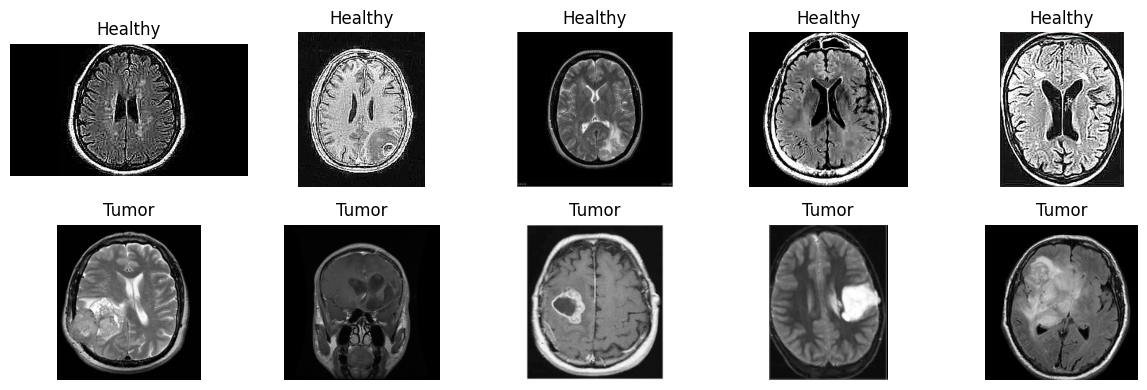

In [34]:
import numpy as np

plt.figure(figsize=(12,4))
for class_id, name in enumerate(class_names):
    idx = np.where(test_true == class_id)[0]
    for i in range(5):  # Show 5 per class
        ax = plt.subplot(2, 5, class_id*5+i+1)
        img = Image.open(test_df.iloc[idx[i]]["filepath"])
        plt.imshow(img, cmap="gray")
        plt.title(name)
        plt.axis("off")
plt.tight_layout()
plt.show()


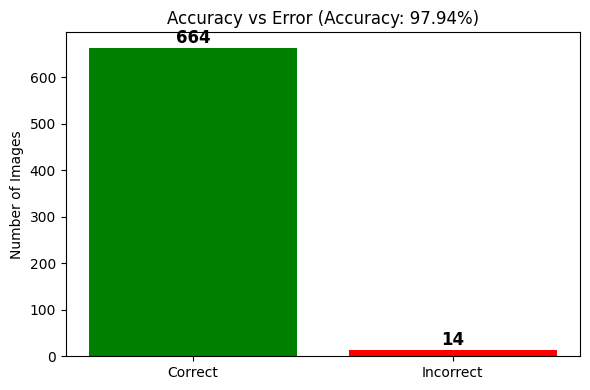

In [29]:
# Bar chart for accuracy vs error
counts = [total_correct, total_wrong]
labels = ['Correct', 'Incorrect']
colors = ['green', 'red']

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=colors)
for i, count in enumerate(counts):
    plt.text(i, count+1, str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.title(f'Accuracy vs Error (Accuracy: {(total_correct/total_images)*100:.2f}%)')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()


In [39]:
model.save("final_brain_tumor_model_97.keras")
print("Saved final model.")

Saved final model.


In [23]:
test_pred = model.predict(test_ds)
test_classes = (test_pred > best_thresh).astype(int).flatten()
test_true = test_df["class_id"].values

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step


Total test images: 678
✔️ True Positives: 664
❌ Wrong Predictions: 14
✅ Test Accuracy: 97.94%


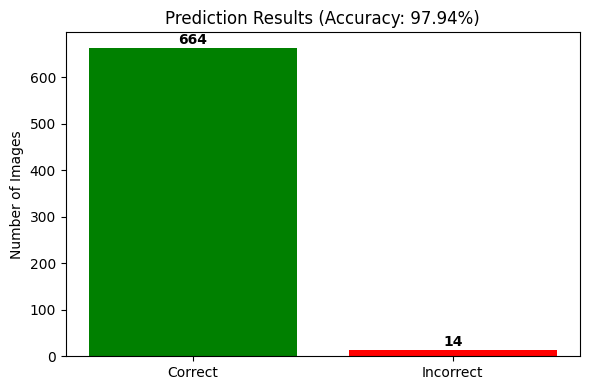

In [24]:
# Total images
total_images = len(test_true)

# Correct and wrong counts
total_correct = np.sum(test_classes == test_true)
total_wrong = np.sum(test_classes != test_true)

print(f"Total test images: {total_images}")
print(f"✔️ True Positives: {total_correct}")
print(f"❌ Wrong Predictions: {total_wrong}")
print(f"✅ Test Accuracy: {(total_correct/total_images)*100:.2f}%")

# Optional: Plot a bar graph of correct vs wrong
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(['Correct', 'Incorrect'], [total_correct, total_wrong], color=['green', 'red'])
for i, count in enumerate([total_correct, total_wrong]):
    plt.text(i, count+1, str(count), ha='center', va='bottom', fontweight='bold')
plt.title(f'Prediction Results (Accuracy: {(total_correct/total_images)*100:.2f}%)')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()


In [25]:
wrong_idx = np.where(test_classes != test_true)[0]
print(f"Indexes of misclassified images: {wrong_idx}")


Indexes of misclassified images: [ 61  74  91 109 158 167 298 356 456 465 494 535 598 636]


In [26]:
class_names = ["Healthy", "Tumor"]

# Get filepaths, true, and predicted labels of wrong predictions
wrong_filepaths = test_df.iloc[wrong_idx]["filepath"].values
wrong_true_labels = test_true[wrong_idx]
wrong_pred_labels = test_classes[wrong_idx]

for i in range(len(wrong_idx)):
    print(f"{i+1}. Path: {wrong_filepaths[i]}")
    print(f"   True Label: {class_names[wrong_true_labels[i]]}, Predicted: {class_names[wrong_pred_labels[i]]}\n")


1. Path: /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor/cancer_(836).jpg
   True Label: Tumor, Predicted: Healthy

2. Path: /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor/cancer_(555).jpg
   True Label: Tumor, Predicted: Healthy

3. Path: /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor/cancer_(2351).jpg
   True Label: Tumor, Predicted: Healthy

4. Path: /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/healthy/not_cancer__(435).jpg
   True Label: Healthy, Predicted: Tumor

5. Path: /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor/cancer_(1615).jpg
   True Label: Tumor, Predicted: Healthy

6. Path: /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumor/cancer_(1574).jpg
   True Label: Tumor, Predicted: Healthy

7. Path: /content/brian-tumor-dataset/Brain Tumor Data Set/brain_tumor_data_set/brain_tumo

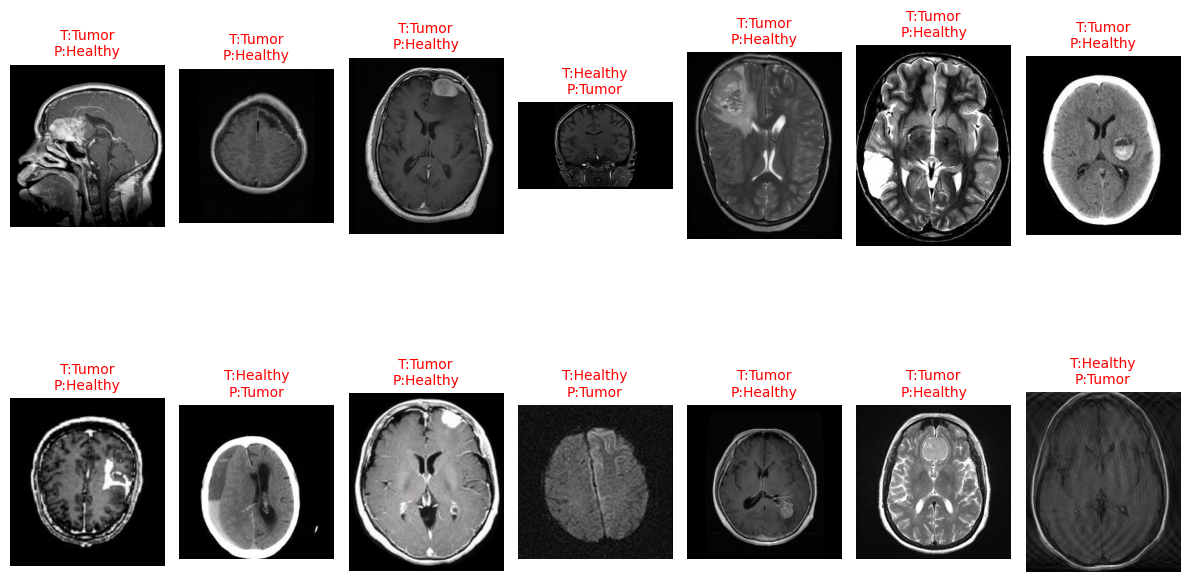

In [27]:
import matplotlib.pyplot as plt
from PIL import Image

n_wrong = min(14, len(wrong_idx))  # change to show up to the total number of wrong images
plt.figure(figsize=(12, 8))
for i in range(n_wrong):
    ax = plt.subplot(2, 7, i+1)
    img = Image.open(wrong_filepaths[i])
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{class_names[wrong_true_labels[i]]}\nP:{class_names[wrong_pred_labels[i]]}", color="red", fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()


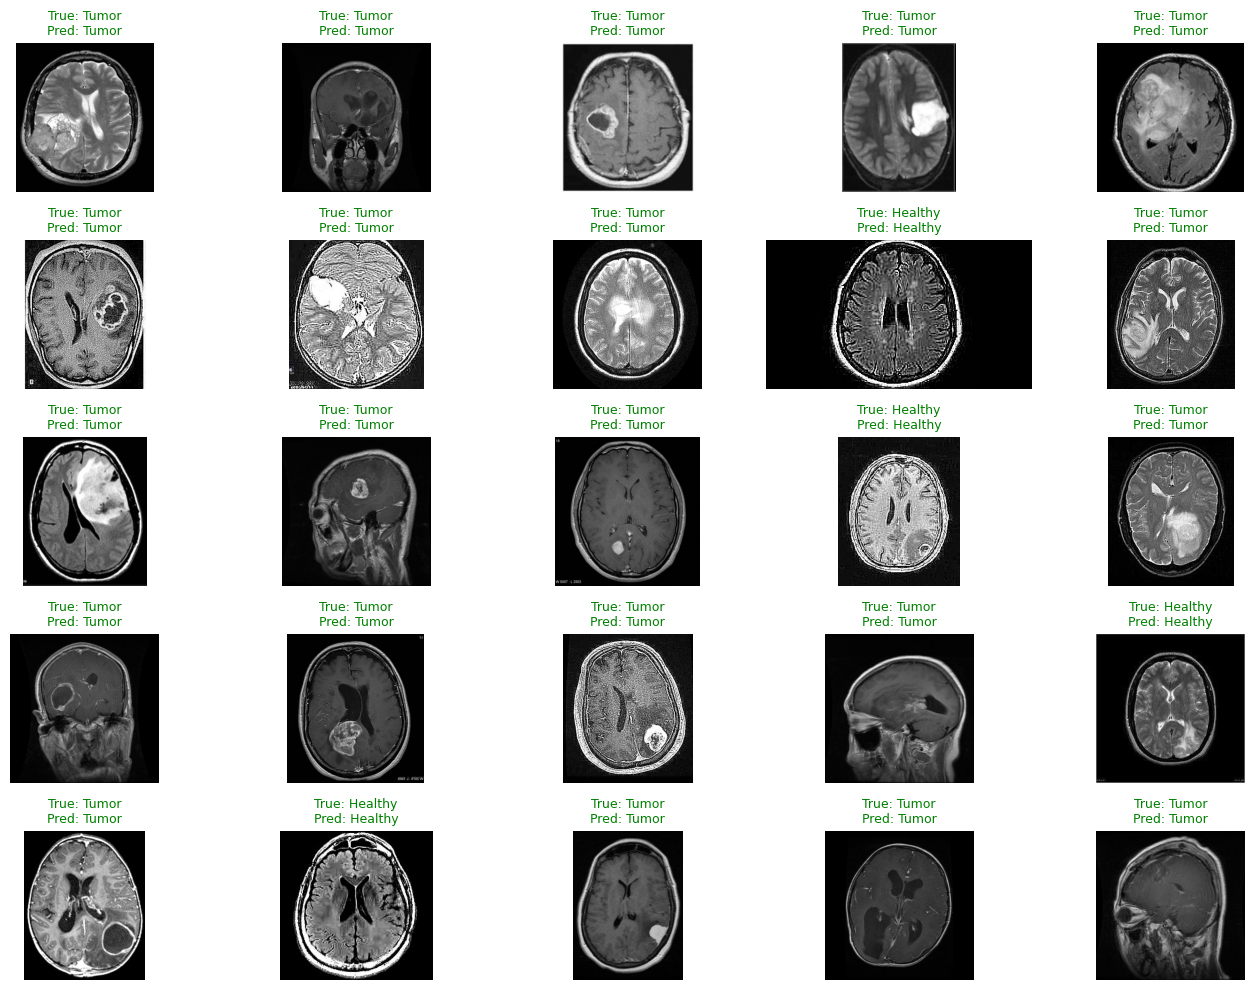

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

class_names = ["Healthy", "Tumor"]

# Find correct prediction indexes
correct_idx = np.where(test_classes == test_true)[0]

# Get correct image paths and labels
correct_filepaths = test_df.iloc[correct_idx]["filepath"].values
correct_true_labels = test_true[correct_idx]
correct_pred_labels = test_classes[correct_idx]

n_show = min(25, len(correct_idx))

plt.figure(figsize=(14,10))
for i in range(n_show):
    ax = plt.subplot(5, 5, i+1)
    img = Image.open(correct_filepaths[i])
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {class_names[correct_true_labels[i]]}\nPred: {class_names[correct_pred_labels[i]]}", color="green", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


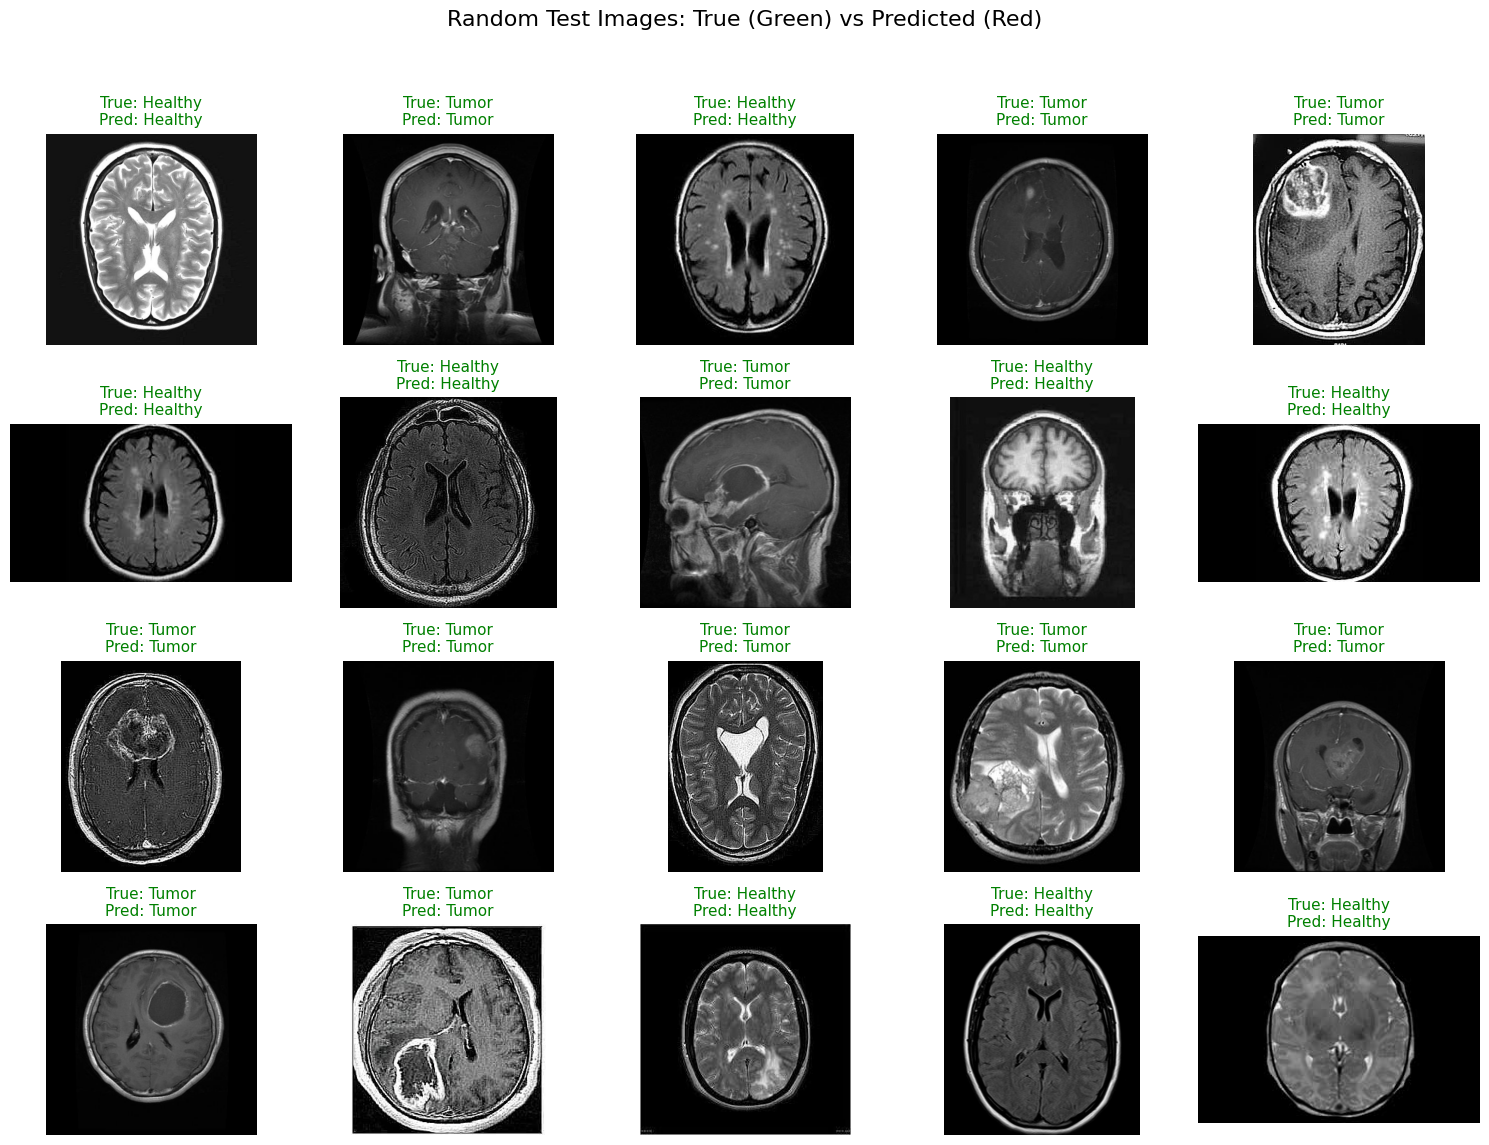

In [37]:
import math
import random
import matplotlib.pyplot as plt
from PIL import Image

class_names = ["Healthy", "Tumor"]

n_samples = 20  # Pick how many images you want to see

random_idx = random.sample(range(len(test_df)), n_samples)

# Dynamically choose grid size (e.g. 4 rows x 5 cols for 20 samples)
n_cols = min(5, n_samples)
n_rows = math.ceil(n_samples / n_cols)

plt.figure(figsize=(3 * n_cols, 3 * n_rows))
for i, idx in enumerate(random_idx):
    img_path = test_df.iloc[idx]["filepath"]
    true_lbl = test_true[idx]
    pred_lbl = test_classes[idx]

    ax = plt.subplot(n_rows, n_cols, i+1)
    img = Image.open(img_path)
    plt.imshow(img, cmap="gray")
    color = "green" if true_lbl == pred_lbl else "red"
    plt.title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}", color=color, fontsize=11)
    plt.axis("off")

plt.suptitle("Random Test Images: True (Green) vs Predicted (Red)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


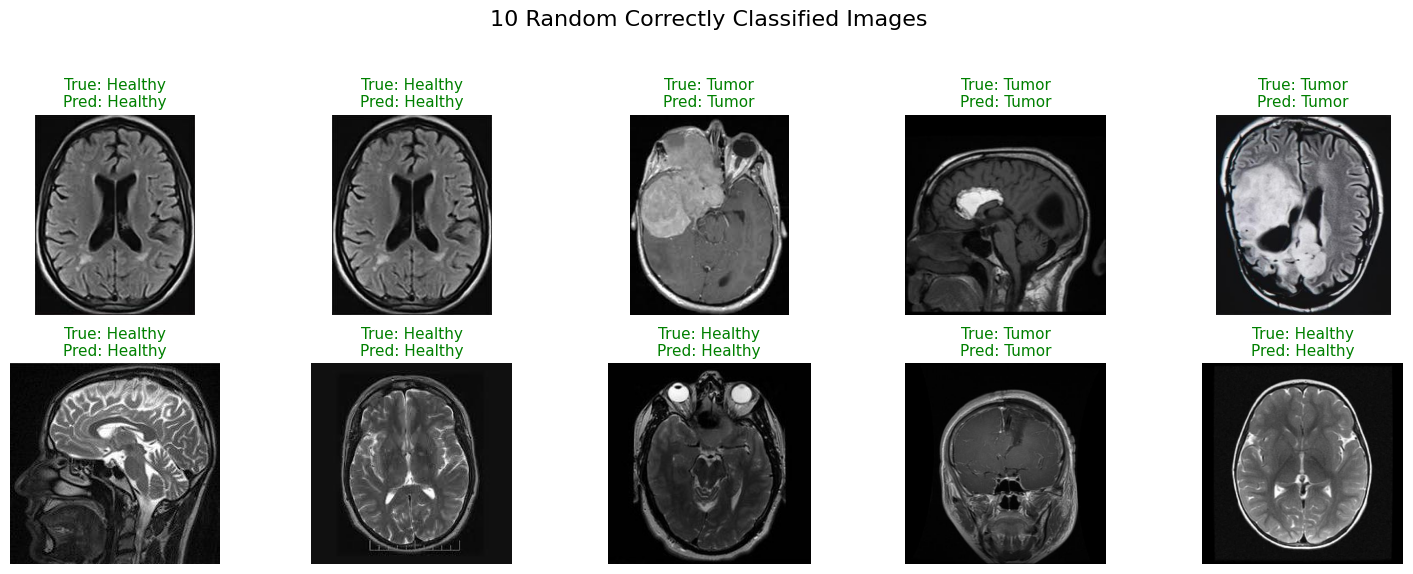

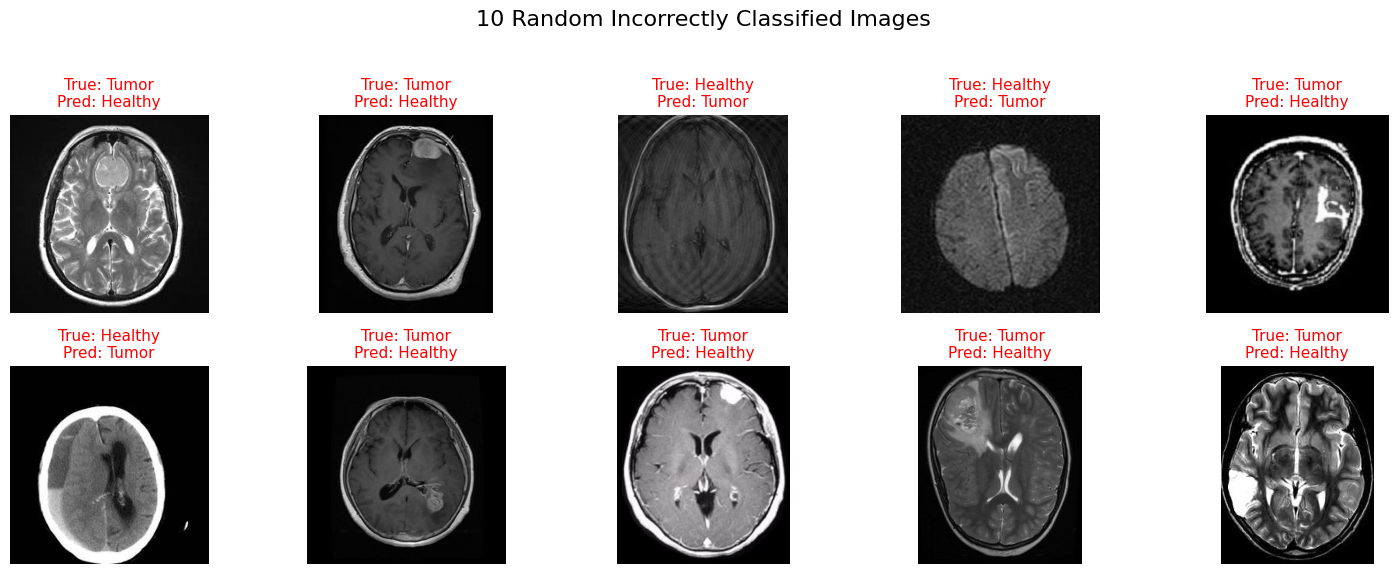

In [38]:
import random
import matplotlib.pyplot as plt
from PIL import Image

class_names = ["Healthy", "Tumor"]

# Find correct and incorrect indexes
correct_idx = np.where(test_classes == test_true)[0]
wrong_idx = np.where(test_classes != test_true)[0]

n_show = 10  # Number of images from each group

# Sample random indexes for each group
rand_correct = random.sample(list(correct_idx), min(n_show, len(correct_idx)))
rand_wrong = random.sample(list(wrong_idx), min(n_show, len(wrong_idx)))

# Helper for neat grid plotting
def plot_image_grid(indexes, color, title, n_cols=5):
    n_imgs = len(indexes)
    n_rows = (n_imgs + n_cols - 1) // n_cols
    plt.figure(figsize=(3 * n_cols, 3 * n_rows))
    for i, idx in enumerate(indexes):
        img_path = test_df.iloc[idx]["filepath"]
        true_lbl = test_true[idx]
        pred_lbl = test_classes[idx]
        ax = plt.subplot(n_rows, n_cols, i+1)
        img = Image.open(img_path)
        plt.imshow(img, cmap="gray")
        plt.title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}", color=color, fontsize=11)
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Show 10 randomly sampled correct predictions
plot_image_grid(rand_correct, color="green", title="10 Random Correctly Classified Images")

# Show 10 randomly sampled incorrect predictions
plot_image_grid(rand_wrong, color="red", title="10 Random Incorrectly Classified Images")

In [40]:
import pandas as pd

# Example: test set output
result_df = test_df.copy()
result_df['predicted_class'] = test_classes
result_df['confidence'] = test_pred.flatten()
result_df['correct'] = (result_df['class_id'] == result_df['predicted_class'])

# Save/export to CSV
result_df.to_csv('model_predictions.csv', index=False)


In [41]:
import pandas as pd
data=pd.read_csv("model_predictions.csv")
data

,filepath,label,class_id,predicted_class,confidence,correct
0,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1,1,0.958726,True
1,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1,1,0.975611,True
2,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1,1,0.988692,True
3,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1,1,0.986168,True
4,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1,1,0.855254,True
...,...,...,...,...,...,...
673,/content/brian-tumor-dataset/Brain Tumor Data ...,healthy,0,0,0.000953,True
674,/content/brian-tumor-dataset/Brain Tumor Data ...,healthy,0,0,0.016443,True
675,/content/brian-tumor-dataset/Brain Tumor Data ...,tumor,1,1,0.954984,True
676,/content/brian-tumor-dataset/Brain Tumor Data ...,healthy,0,0,0.009578,True


In [43]:
len(data[data['correct']==False])

14

In [44]:
import pandas as pd

hist_df = pd.DataFrame(history1.history)
hist_df.to_csv("training_history.csv", index=False)


In [45]:
import pandas as pd

hist_df = pd.DataFrame(history2.history)
hist_df.to_csv("training_history_2.csv", index=False)


# images

In [ ]:
import pandas as pd

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)


In [ ]:
import numpy as np
import tensorflow as tf

def preprocess_image(path, img_size=(224,224)):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, img_size)
    return img.numpy()

all_images = np.stack([preprocess_image(f) for f in all_df['filepath'].values])
model = tf.keras.models.load_model('/content/final_brain_tumor_model_97.keras')

all_preds = model.predict(all_images, batch_size=32, verbose=1)
all_pred_classes = (all_preds > 0.5).astype(int).flatten()


In [ ]:
all_df['predicted_class'] = all_pred_classes
all_df['confidence'] = all_preds.flatten()
all_df['correct'] = (all_df['class_id'] == all_df['predicted_class'])

# Optionally, map class IDs to names
class_names = {0: "Healthy", 1: "Tumor"}
all_df['true_label'] = all_df['class_id'].map(class_names)
all_df['predicted_label'] = all_df['predicted_class'].map(class_names)

# Save to CSV
all_df.to_csv("all_image_predictions.csv", index=False)

print("CSV with all image predictions saved as all_image_predictions.csv")